# Classical time series analysis
This notebook tracks my efforts to find a competitive classical time series model that can serve as a benchmark against which I'd like to compare my quantum reservoir computing model.

Loading data from file
(841536, 26)


(array([660000., 680000., 700000., 720000., 740000., 760000., 780000.,
        800000., 820000., 840000., 860000.]),
 [Text(660000.0, 0, '660000'),
  Text(680000.0, 0, '680000'),
  Text(700000.0, 0, '700000'),
  Text(720000.0, 0, '720000'),
  Text(740000.0, 0, '740000'),
  Text(760000.0, 0, '760000'),
  Text(780000.0, 0, '780000'),
  Text(800000.0, 0, '800000'),
  Text(820000.0, 0, '820000'),
  Text(840000.0, 0, '840000'),
  Text(860000.0, 0, '860000')])

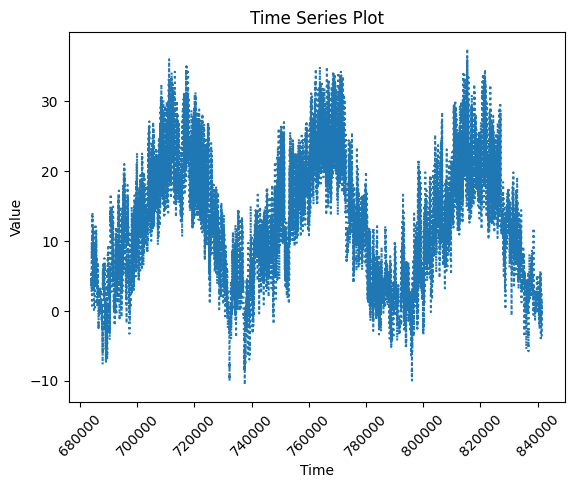

In [1]:
import os.path

from src.data.loading.configs import MODEL_DIR_CLASSICAL
# ---- load data ----
from src.data.loading.geosphere import Geosphere

data = Geosphere().load_data_into_memory()

print(data.shape)

historically_relevant_data = data[-(144*365*3):]

import matplotlib.pyplot as plt

plt.plot(historically_relevant_data.index, historically_relevant_data['tl'], linestyle = 'dotted')

# Add title and axis labels
plt.title('Time Series Plot')
plt.xlabel('Time')
plt.ylabel('Value')
plt.xticks(rotation=45)

In [2]:
# ---- select data ----

import pandas as pd

selected_columns = [
    'cglo'
    , 'chim'
    , 'dd'
    , 'ddx'
    , 'ff'
#    , 'ffam_flag'
    , 'ffx'
    , 'p'
#    , 'pred'
    , 'rf'
    , 'rr'
    , 'rrm'
    , 'sh'
    , 'so'
    , 'tb10'
    , 'tb20'
    , 'tb50'
    , 'tl'
    , 'tlmax'
    , 'tlmin'
    , 'ts'
    , 'tsmax'
    , 'tsmin'
    , 'zeitx'
    , 'timestamps'
#    , 'stationId'
]

usable_data = historically_relevant_data.dropna(axis="columns", how="all")

final_data_columns = usable_data.columns.intersection(selected_columns)

final_data = historically_relevant_data[final_data_columns].reset_index(drop=True)
final_data.set_index(pd.to_datetime(final_data['timestamps'], format="ISO8601"))
final_data.index.freq = '10min'

# output
print("Selected columns: {}".format(selected_columns))
print("Usable columns: {}".format(usable_data.columns))
print("Realised columns: {}".format(final_data_columns))
print("Final data dimensions: {}".format(final_data.shape))

Selected columns: ['cglo', 'chim', 'dd', 'ddx', 'ff', 'ffx', 'p', 'rf', 'rr', 'rrm', 'sh', 'so', 'tb10', 'tb20', 'tb50', 'tl', 'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx', 'timestamps']
Usable columns: Index(['cglo', 'dd', 'ddx', 'ff', 'ffam_flag', 'ffx', 'p', 'pred', 'rf', 'rr',
       'rrm', 'so', 'tl', 'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx',
       'timestamps', 'stationId'],
      dtype='object')
Realised columns: Index(['cglo', 'dd', 'ddx', 'ff', 'ffx', 'p', 'rf', 'rr', 'rrm', 'so', 'tl',
       'tlmax', 'tlmin', 'ts', 'tsmax', 'tsmin', 'zeitx', 'timestamps'],
      dtype='object')
Final data dimensions: (157680, 18)


In [3]:
import pickle
# ---- model selection ----

# parameters of the time-series:
# - one-dimensional
# - value 'tl'

# tried but failed due to conflicting dependencies:
# Seshadri, Ram (2020). GitHub - AutoViML/Auto_TS: enables you to build and deploy multiple time
# series models using ML and statistical techniques with a single line of code.
# Source code: https://github.com/AutoViML/Auto_TS

# instead used:
import pmdarima as pm

train, test = pm.model_selection.train_test_split(final_data['tl'],
                                                  train_size=144*1000)
train_array, test_array = train.to_numpy().reshape(-1,1), test.to_numpy().reshape(-1,1)

# reload/select best model
from src.data.loading.configs import MODEL_DIR_CLASSICAL
file = MODEL_DIR_CLASSICAL / 'arima_model.pkl'

if os.path.exists(file):    # load
    classical_model = pickle.load(open(file, "rb"))
else:   # select best model according to the data and fits model to data
    classical_model = pm.auto_arima(train,
                        seasonal=False,
                        # m=144, # 144 Intervalle à 10min = 24 Stunden Saison
                        max_p=4,
                        max_d=2,
                        max_q=4,
                        error_action='ignore',
                        suppress_warnings=True,
                        stepwise=True,
                        trace=True)
    # dump arima model to avoid recalculation
    with open(file, 'wb') as pkl:
        pickle.dump(classical_model, pkl)

print("The type of the model is: {}".format(type(classical_model)))
print("Its parameters are: {}".format(classical_model))

The type of the model is: <class 'pmdarima.arima.arima.ARIMA'>
Its parameters are:  ARIMA(1,1,4)(0,0,0)[0]          


In [4]:
# ---- model prediction ----
# forecast, conf_int = classical_model.predict_in_sample(n_periods=72, return_conf_int=True)
in_sample_prediction = classical_model.predict_in_sample()

print("Forecast: {}".format(in_sample_prediction))
# print("Conf int: {}".format(conf_int))



Forecast: 0          0.000000
1          5.400000
2          5.400000
3          5.400000
4          5.400000
            ...    
143995    14.079193
143996    14.084978
143997    14.087782
143998    14.201905
143999    14.093475
Name: predicted_mean, Length: 144000, dtype: float64


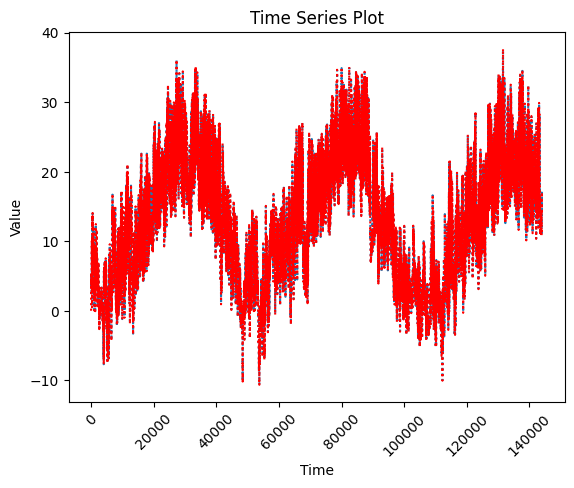

In [5]:
# evaluate model
import numpy as np
# --------------------------------------------------------------------------------------
# visual assessment of goodness of fit
# in-sample prediction
plt.plot(train.index, train, linestyle = 'dotted')
plt.plot(train.index, in_sample_prediction, linestyle = 'dotted', color = 'red')

# Add title and axis labels
plt.title('Time Series Plot')
plt.xlabel('Time')
plt.ylabel('Value')
plt.xticks(rotation=45)

# Display the plot
plt.show()
# --------------------------------------------------------------------------------------
# --------------------------------------------------------------------------------------
# calculate average prediction error of in-sample-predictions (make this a little more technical)
# mean_error = np.mean(np.fabs(np.subtract(in_sample_prediction, train_array)))
# print("Mean error: {}".format(mean_error))

# std_error = np.std(np.subtract(in_sample_prediction, train_array))
# print("Standard deviation: {}".format(std_error))